# Generador de archivos ROOT con valores de $\frac{dR}{dE}$ para las diferentes librerias

OJO - La primera vez que se ejecuta este notebook se recomienda leer y revisar paso por paso, una vez se tenga todo seguro ya se puede ejecutar todo de vez.

### IMPORTS

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos
import numpy as np    # librería numérica
import matplotlib.pyplot as plt  # para crear gráficos
import math as m


from scipy import special
from scipy.stats import norm


Este código tiene como objetivo calcular el ritmo diferencial esperado en el detector empleando diferentes librerías.

## Instalación de librerías

En primer lugar tenemos que instalar/compilar los paquetes RAPIDD y WIMPYDD, cada una de ellas tiene sus particularidades y su instalación es diferente para cada sistema operativo. Lo que nos interesa es la ruta de instalación, ya que es lo que necesita el código para ubicarlas y poder trabajar con ellas.

En este ejemplo las vamos a instalar en la carpeta: "/libs" por lo que emplearemos la ruta relativa desde la ubicación del archivo. En caso de instalarlos en otra ubicación deberemos usar la ruta absoluta de la carpeta.

In [2]:
#Ruta de la carpeta donde se encuentra WIMPYDD
WIMPYDD_rel_path = 'Libs/WIMPYDD'


WIMPYDD_abs_path = os.path.realpath(WIMPYDD_rel_path)   
sys.path.append(WIMPYDD_abs_path)


print(WIMPYDD_abs_path)

/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD


In [3]:
#Ruta de la carpeta donde se encuentra RAPIDD
RAPIDD_rel_path = 'Libs/RAPIDD'

RAPIDD_rel_path = RAPIDD_rel_path + '/rapidd' 
RAPIDD_abs_path = os.path.realpath(RAPIDD_rel_path)   
sys.path.append(RAPIDD_abs_path)
print(RAPIDD_abs_path)

/home/borja/Documents/TFG/GeneraRitmo/Libs/RAPIDD/rapidd


In [4]:
#Ruta de la carpeta donde se encuentra el codigo ANAIS
ANAIS_rel_path = 'Libs/ANAIS'


ANAIS_abs_path = os.path.realpath(ANAIS_rel_path)   
sys.path.append(ANAIS_abs_path)
print(ANAIS_abs_path)

/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS


## Importamos las librerías necesarias

Procedemos a incorporar las librerías al código y de esta forma poder usar sus funciones.

In [5]:
#Importamos ANAIS

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

In [6]:
#Importamos WIMPYDD

from package import *

In [7]:
#Importamos RAPIDD

from core import base_dir, reset_coefficients, isofromneuc, set_any_Ncoeff, read_halo, difrate_dER

## POSIBLES FALLOS

Suele dar problemas con las versiones mas recientes de python. A mi me funciona con la 3.9.12.

##### WIMPYDD

Esta librería es la que mas fallos me ha dado a la hora de importarla, como solución he modificado el archivo "package.py" quitando alguna cosa que daba problemas y que en principio no vamos a usar (Los elementos Calcio y Wolframio). El archivo modificado esta en la carpeta "/Patch". Hay que copiarlo en la carpeta donde se encuentre instalada la libreria. 

Ademas, hay que modificar la linea 158 con la ruta absoluta donde se encuentre instalada la libreria. (Mas arriba se imprime esta ruta al importar las librerias)

## Importar las nuevas funciones

In [8]:
@np.vectorize
def diffrate_mod(mass, er, rho=.3, target='Na', basis='All',
                 day=22, month=3, halo_dir=RAPIDD_abs_path+"/halo_tables/"):
    # Comprueba que el fichero exista
    halo_file = f"{halo_dir}halo_{month}_{day}.dat"
    if not os.path.exists(halo_file):
        raise FileNotFoundError(f"File not found: {halo_file}")

    # Lee el halo (el propio `read_halo` suele cambiar
    #     algún estado global, de modo que la llamada sea necesaria)
    read_halo(halo_file)

    # Evalúa la función `difrate_dER` para cada (mass, er)
    #     y lo vuelve vectorizado una segunda vez.
    #     (La primera vectorización proviene del decorador @np.vectorize)
    return np.vectorize(difrate_dER)(rho, mass, er,
                                     target=target, basis=basis)

@np.vectorize
def modulation(mass, er, rho=.3, target='Na', basis='All', halo_dir = RAPIDD_abs_path + "/halo_tables/"):

    if not(os.path.exists(halo_dir+'halo_6_1.dat')):
        raise FileNotFoundError(f"File not found: {halo_dir+'halo_6_1.dat'}")
    if not(os.path.exists(halo_dir+'halo_12_1.dat')):
        raise FileNotFoundError(f"File not found: {halo_dir+'halo_12_1.dat'}")

    read_halo(halo_dir+'halo_6_1.dat')
    a = np.vectorize(difrate_dER)(rho, mass, er, target=target, basis=basis)
    read_halo(halo_dir+'halo_12_1.dat')
    b = np.vectorize(difrate_dER)(rho, mass, er, target=target, basis=basis)
    
    return .5*(a-b)

@np.vectorize
def rate_av(mass, er, rho=.3, target='Ge', basis='All', output_dir = RAPIDD_abs_path +"/halo_tables/"):

    if not(os.path.exists(output_dir+'halo_6_1.dat')) or not(os.path.exists(output_dir+'halo_12_1.dat')):
        print("Halo File not found!!!")
        return

    read_halo(output_dir+'halo_6_1.dat')
    a = np.vectorize(difrate_dER)(rho, mass, er, target=target, basis=basis)
    read_halo(output_dir+'halo_12_1.dat')
    b = np.vectorize(difrate_dER)(rho, mass, er, target=target, basis=basis)
    
    return .5*(a+b)

import numpy as np

def numero_a_fecha(numero_dia):

    numero_dia=numero_dia+81

    if numero_dia>365:
        numero_dia=numero_dia-365
    
    dias_por_mes = [
        31, 28, 31,  # enero, febrero, marzo
        30, 31, 30,  # abril, mayo, junio
        31, 31, 30,  # julio, agosto, septiembre
        31, 30, 31   # octubre, noviembre, diciembre
    ]

    dia_restante = numero_dia
    for mes, dias in enumerate(dias_por_mes):
        if dia_restante <= dias:
            dia = dia_restante
            return int(dia), int(mes) + 1
        dia_restante -= dias

def print_mw_c(a: float = 3.0,
               b: float = 1.75e4,
               n: int   = 150,
               fmt: str = "{: .8e}",
               elems_per_line: int = 8,
               var_name: str = "mw",
               const: bool = True) -> None:
    """
    Genera el vector geométricamente espaciado con np.geomspace y lo imprime
    como un literal de array de C que puedes copiar‑y‑pegar directamente.

    Parámetros
    ----------
    a, b : float
        Extremos del rango geométrico.
    n : int
        Cantidad de puntos (valor por defecto 150).
    fmt : str
        Formato de cada número (por defecto 8 decimales en notación exponencial).
    elems_per_line : int
        Cantidad de elementos por línea (para mejorar la legibilidad).
    var_name : str
        Nombre de la variable C que se declarará.
    const : bool
        Si True se añade `const` al principio de la declaración.
    """
    # 1. Generamos el vector
    arr = np.geomspace(a, b, n)

    # 2. Construimos la línea de apertura
    const_str = "const " if const else ""
    header = f"static {const_str}double {var_name}[{n}] = {{"
    print(header)

    # 3. Imprimimos los valores, 8 por línea (puedes cambiar `elems_per_line`)
    line = "    "  # sangría de 4 espacios
    for i, val in enumerate(arr, start=1):
        line += fmt.format(val) + ", "
        if i % elems_per_line == 0:
            # terminamos la línea
            print(line.rstrip(", "))
            line = "   ,"  # reiniciamos sangría

    # Si quedó algo sin imprimir
    if line.strip():
        print(line.rstrip(", "))

    # 4. Cierre
    print("};")
    
def _fmt_val(val: float) -> str:
    """
    Devuelve la cadena de `val` con:
        * 2 decimales por defecto
        * Si el último decimal es 0 → se muestra una sola cifra decimal
        * Si ambos decimales son 0 → se muestra “.0”
    """
    s = f"{val:.2f}"          # 3.00 → "3.00", 3.10 → "3.10", 3.12 → "3.12"
    s = s.rstrip('0').rstrip('.')  # 3.00→"3", 3.10→"3.1", 3.12→"3.12"

    # Si quedó sin punto, añadimos ".0" (caso 3.00)
    if '.' not in s:
        s += ".0"
    return s

def print_hist_mw_c(mw: np.ndarray,
                    var_name: str = "hist_mw",
                    elems_per_line: int = 6,
                    const: bool = True) -> None:
    """
    Imprime en stdout una declaración C de un array de cadenas con el
    nombre `hist_mw_<valor>`.  
    Se usa la función interna `_fmt_val` para el formato solicitado.
    """
    const_str = "const " if const else ""
    n = len(mw)

    print(f"static {const_str}const char *{var_name}[{n}] = {{")
    line = "    "

    for i, v in enumerate(mw, start=1):
        txt = f"hist_mw_{_fmt_val(v)}"
        line += f'"{txt}", '
        if i % elems_per_line == 0:
            print(line.rstrip(", "))
            line = "   ,"

    if line.strip():               # resto de elementos que no llenaron la línea
        print(line.rstrip(", "))
    print("};")

#Funciones para RAPIDD

def ObtainSectionSI(mx,c): 
    
    ##mN= A*mn
    ##Res=16*np.pi*(mN+mx)**2
    ##si=c*c/Res
    ##si=si*1.9733E-16*1.9733E-16
    ##return(si)

    mv=246
    mN=mn
    mu=mx*mN/(mx+mN)
    
    si=mu*mu*c*c/np.pi/mv/mv/mv/mv
    si=si*1.9733E-16*1.9733E-16*1000
    return(si)

def ObtainCoefficientSI(mx,si): 

    hbarc2=0.38938e-27
    mv=246
    mN=mn
    mu=mx*mN/(mx+mN)
    c=mv*mv/mu*np.sqrt(np.pi*si/hbarc2)
    return(c)

def rate_RAPIDD_Na(Eee,mW,sigmaSI,t,Q=1):

    fecha=numero_a_fecha(t)

    c=ObtainCoefficientSI(mW,sigmaSI)
    
    reset_coefficients()
    
    set_any_Ncoeff(c, 1, "p")
    set_any_Ncoeff(c, 1, "n")

    E=Eee/Q
    drde = diffrate_mod(mW, E, day=fecha[0], month=fecha[1], target='Na')
    drde/=Q

    return drde
    
def rate_RAPIDD_I(Eee,mW,sigmaSI,t,Q=1):

    fecha=numero_a_fecha(t)

    c=ObtainCoefficientSI(mW,sigmaSI)
    
    reset_coefficients()
    set_any_Ncoeff(c, 1, "p")
    set_any_Ncoeff(c, 1, "n")

    E=Eee/Q
    drde = diffrate_mod(mW, E, day=fecha[0], month=fecha[1], target='I')
    drde/=Q

    return drde

def rate_RAPIDD(Eee,mW,sigmaSI,t, QNa=1, QI=1):


    rateNa = rate_RAPIDD_Na(Eee,mW,sigmaSI,t,QNa)
    rateI = rate_RAPIDD_I(Eee,mW,sigmaSI,t,QI)
 
    return (rateNa*23.+rateI*127.)/(23.+127.)

def totalRate_RAPIDD(Eiee,Efee,t,mW,sigmaSI):
  energy_ee = np.arange(Eiee,Efee,0.1)
  qfNa = getQFNa(energy_ee)
  qfI = getQFI(energy_ee)
  rates = np.array([
        rate_RAPIDD(e, mW, sigmaSI,t, qna, qi)
        for e, qna, qi in zip(energy_ee, qfNa, qfI)
    ])

  return rates.sum()*0.1

def numero_cuentas_teo_RAPIDD(Eiee,Efee,t,mW,sigmaSI,array_det=np.ones(9,dtype=int)):
  Matriz=np.eye(9)
  exp=0
  for i in range(9):
          if(array_det[i]==1):
            texp=calcula_t_exposicion(i)
            mexp=calcula_m_exposicion(i)
            exp+=texp*mexp
  retval=totalRate_RAPIDD(Eiee,Efee,t,mW,sigmaSI)
  return retval*exp

def calcula_sigma_RAPIDD(E_i,E_f,mW,t,cl=0.9,array_det=np.ones(9,dtype=int)):
    N_teo=numero_cuentas_teo_RAPIDD(E_i,E_f,t,mW,1,array_det)
    N_exp=numero_cuentas_exp_CL(E_i,E_f,cl,array_det)
    return N_exp/N_teo

#Funciones para WIMPYDD

def rate_WIMPYDD_Na(Eee,mW,sigmaSI,t,Q=1):
    
    wc_SI = {1: lambda: c_tau_SI(sigmaSI, mW, cn_over_cp=1)}
    SI = eft_hamiltonian('Spin-independent', wc_SI)
    na=target('Na') 
    vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81,v_rot_gal=v0,v_sun_rot=vpec) 
    #vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81) 

    E=Eee/Q
    diff_rate_na=diff_rate(target=na, hamiltonian=SI, mchi=mW, energy=E,vmin=vmin, delta_eta=delta_eta0)
    diff_rate_na/=Q
    return diff_rate_na
    
def rate_WIMPYDD_I(Eee,mW,sigmaSI,t,Q=1):
    
    

    wc_SI = {1: lambda: c_tau_SI(sigmaSI, mW, cn_over_cp=1)}
    SI = eft_hamiltonian('Spin-independent', wc_SI)
    I=target('I') 
    vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81,v_rot_gal=v0,v_sun_rot=vpec) 
    #vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81) 
    
    E=Eee/Q
    diff_rate_I=diff_rate(target=I, hamiltonian=SI, mchi=mW, energy=E,vmin=vmin, delta_eta=delta_eta0)
    diff_rate_I/=Q
    return diff_rate_I

def rate_WIMPYDD(Eee,mW,sigmaSI,t, QNa=1, QI=1):


    rateNa = rate_WIMPYDD_Na(Eee,mW,sigmaSI,t,QNa)
    rateI = rate_WIMPYDD_I(Eee,mW,sigmaSI,t,QI)
 
    return (rateNa*23.+rateI*127.)/(23.+127.)

def totalRate_WIMPYDD(Eiee,Efee,mW,sigmaSI,t):
  energy_ee = np.arange(Eiee,Efee,0.1)
  qfNa = getQFNa(energy_ee)
  qfI = getQFI(energy_ee)
  rates = np.array([
        rate_WIMPYDD(e, mW, sigmaSI,t, qna, qi)
        for e, qna, qi in zip(energy_ee, qfNa, qfI)
    ])

  return rates.sum()*0.1

def numero_cuentas_teo_WIMPYDD(Eiee,Efee,t,mW,sigmaSI,array_det=np.ones(9,dtype=int)):
  Matriz=np.eye(9)
  exp=0
  for i in range(9):
          if(array_det[i]==1):
            texp=calcula_t_exposicion(i)
            mexp=calcula_m_exposicion(i)
            exp+=texp*mexp
  retval=totalRate_WIMPYDD(Eiee,Efee,mW,sigmaSI,t)
  return retval*exp

def calcula_sigma_WIMPYDD(E_i,E_f,mW,t,cl=0.9,array_det=np.ones(9,dtype=int)):
    N_teo=numero_cuentas_teo_WIMPYDD(E_i,E_f,t,mW,1,array_det)
    N_exp=numero_cuentas_exp_CL(E_i,E_f,cl,array_det)
    return N_exp/N_teo
    

In [9]:

mw_arr = []
for imw in range(2, 10):      # 5, 6, 7, 8, 9
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a)

for imw in range(1, 10):
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a * 10)

for imw in range(1, 10):
    for j in range (4):
        a=imw+0.2*j     # 1, 2, …, 10
        mw_arr.append(a * 100)

for imw in range(1, 11):
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a * 1000)

print(len(mw_arr))
print(mw_arr)
mw_arr=np.array(mw_arr)
mw_arr=np.round(mw_arr,1)
print(mw_arr)

144
[2.0, 2.2, 2.4, 2.6, 3.0, 3.2, 3.4, 3.6, 4.0, 4.2, 4.4, 4.6, 5.0, 5.2, 5.4, 5.6, 6.0, 6.2, 6.4, 6.6, 7.0, 7.2, 7.4, 7.6, 8.0, 8.2, 8.4, 8.6, 9.0, 9.2, 9.4, 9.6, 10.0, 12.0, 14.0, 16.0, 20.0, 22.0, 24.0, 26.0, 30.0, 32.0, 34.0, 36.0, 40.0, 42.0, 44.0, 46.0, 50.0, 52.0, 54.0, 56.0, 60.0, 62.0, 64.0, 66.0, 70.0, 72.0, 74.0, 76.0, 80.0, 82.0, 84.0, 86.0, 90.0, 92.0, 94.0, 96.0, 100.0, 120.0, 140.0, 160.0, 200.0, 220.00000000000003, 240.0, 260.0, 300.0, 320.0, 340.0, 360.0, 400.0, 420.0, 440.00000000000006, 459.99999999999994, 500.0, 520.0, 540.0, 560.0, 600.0, 620.0, 640.0, 660.0, 700.0, 720.0, 740.0, 760.0, 800.0, 819.9999999999999, 840.0, 860.0, 900.0, 919.9999999999999, 940.0, 960.0, 1000.0, 1200.0, 1400.0, 1600.0, 2000.0, 2200.0, 2400.0, 2600.0, 3000.0, 3200.0, 3400.0, 3600.0, 4000.0, 4200.0, 4400.0, 4600.0, 5000.0, 5200.0, 5400.0, 5600.0, 6000.0, 6200.0, 6400.0, 6600.0, 7000.0, 7200.0, 7400.0, 7600.0, 8000.0, 8200.0, 8400.0, 8600.0, 9000.0, 9200.0, 9400.0, 9600.0, 10000.0, 10200.0

# Generamos los datos del ritmo diferencial

Primero generamos una lista de masas de wimp entre 2 valores preestablecidos en escala logarítmica

In [10]:
#Numero de puntos del plot
#n_masas=150

#Valor mínimo de masa
#masa_min=3

#Valor máximo de masa
#masa_max=1.75e04

#array_masas=np.geomspace(masa_min,masa_max,n_masas)
array_masas=mw_arr
#print(array_masas)

Exportamos la misma información para poder copiar y pegar en el código de C/C++

In [11]:
print_mw_c()

static const double mw[150] = {
     3.00000000e+00,  3.17977115e+00,  3.37031485e+00,  3.57227663e+00,  3.78634072e+00,  4.01323232e+00,  4.25372011e+00,  4.50861883e+00
   , 4.77879202e+00,  5.06515499e+00,  5.36867789e+00,  5.69038902e+00,  6.03137827e+00,  6.39280086e+00,  6.77588124e+00,  7.18191722e+00
   , 7.61228438e+00,  8.06844074e+00,  8.55193169e+00,  9.06439521e+00,  9.60756744e+00,  1.01832886e+01,  1.07935091e+01,  1.14402962e+01
   , 1.21258413e+01,  1.28524667e+01,  1.36226343e+01,  1.44389532e+01,  1.53041889e+01,  1.62212727e+01,  1.71933117e+01,  1.82235988e+01
   , 1.93156245e+01,  2.04730885e+01,  2.16999120e+01,  2.30002514e+01,  2.43785119e+01,  2.58393629e+01,  2.73877535e+01,  2.90289294e+01
   , 3.07684507e+01,  3.26122106e+01,  3.45664554e+01,  3.66378059e+01,  3.88332793e+01,  4.11603137e+01,  4.36267926e+01,  4.62410721e+01
   , 4.90120089e+01,  5.19489906e+01,  5.50619671e+01,  5.83614847e+01,  6.18587217e+01,  6.55655261e+01,  6.94944560e+01,  7.36588220

Generamos un array con los diferentes valores de energía para el plot de ritmo diferencial. 

In [12]:
#Numero de puntos del plot
n_energias=1000

#Valor mínimo de masa
energias_min=0

#Valor máximo de masa
energias_max=100

energies = np.linspace(energias_min,energias_max,n_energias)

Establecemos el valor de seccion eficaz (1 cm² por defecto)

In [13]:
#sección eficaz SI(cm^-2)
si=1e-36                               

Ejecutamos el calculo. (OJO - Tarda mucho)
### WIMPYDD

In [14]:
matriz_WIMPYDD_Na=np.zeros((len(array_masas),len(energies)))
matriz_WIMPYDD_I=np.zeros((len(array_masas),len(energies)))

si=1e-36                                  # seccion eficaz SI(cm^-2)
emes = array_masas
emes = np.array(emes) 

for j in range(len(emes)):
    mW=emes[j]
    print(mW)
    for i in range(len(energies)):
        matriz_WIMPYDD_I[j,i]=rate_WIMPYDD_I(energies[i],mW,si,timeAvg)
        matriz_WIMPYDD_Na[j,i]=rate_WIMPYDD_Na(energies[i],mW,si,timeAvg)


2e+00


/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:4907: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'mchi' in global_arguments: args['mchi']=mchi
/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:4908: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'delta' in global_arguments: args['delta']=delta
/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:5036: RuntimeWarning: divide by zero encountered in double_scalars
  return 1.0/np.sqrt(2.0*mn*er)*abs(mn*er/mu+delta)*300.
/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:5036: RuntimeWarning: invalid value encountered in double_scalars
  return 1.0/np.sqrt(2.0*mn*er)*abs(mn*er/mu+delta)*300.
/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:5135: RuntimeWarning: invalid value encountered in double_scalars
  eft_n_

2.2e+00
2.4e+00
2.6e+00
3e+00
3.2e+00
3.4e+00
3.6e+00
4e+00
4.2e+00
4.4e+00
4.6e+00
5e+00
5.2e+00
5.4e+00
5.6e+00
6e+00
6.2e+00
6.4e+00
6.6e+00
7e+00
7.2e+00
7.4e+00
7.6e+00
8e+00
8.2e+00
8.4e+00
8.6e+00
9e+00
9.2e+00
9.4e+00
9.6e+00
1e+01
1.2e+01
1.4e+01
1.6e+01
2e+01
2.2e+01
2.4e+01
2.6e+01
3e+01
3.2e+01
3.4e+01
3.6e+01
4e+01
4.2e+01
4.4e+01
4.6e+01
5e+01
5.2e+01
5.4e+01
5.6e+01
6e+01
6.2e+01
6.4e+01
6.6e+01
7e+01
7.2e+01
7.4e+01
7.6e+01
8e+01
8.2e+01
8.4e+01
8.6e+01
9e+01
9.2e+01
9.4e+01
9.6e+01
1e+02
1.2e+02
1.4e+02
1.6e+02
2e+02
2.2e+02
2.4e+02
2.6e+02
3e+02
3.2e+02
3.4e+02
3.6e+02
4e+02
4.2e+02
4.4e+02
4.6e+02
5e+02
5.2e+02
5.4e+02
5.6e+02
6e+02
6.2e+02
6.4e+02
6.6e+02
7e+02
7.2e+02
7.4e+02
7.6e+02
8e+02
8.2e+02
8.4e+02
8.6e+02
9e+02
9.2e+02
9.4e+02
9.6e+02
1e+03
1.2e+03
1.4e+03
1.6e+03
2e+03
2.2e+03
2.4e+03
2.6e+03
3e+03
3.2e+03
3.4e+03
3.6e+03
4e+03
4.2e+03
4.4e+03
4.6e+03
5e+03
5.2e+03
5.4e+03
5.6e+03
6e+03
6.2e+03
6.4e+03
6.6e+03
7e+03
7.2e+03
7.4e+03
7.6e+03
8e+03
8.2e+03
8.

### RAPIDD

In [15]:
matriz_RAPIDD_Na=np.zeros((len(array_masas),len(energies)))
matriz_RAPIDD_I=np.zeros((len(array_masas),len(energies)))

si=1e-36                                 # seccion eficaz SI(cm^-2)
emes = array_masas
emes = np.array(emes) 

for j in range(len(emes)):
    mW=emes[j]
    print(mW)
    for i in range(len(energies)):
        matriz_RAPIDD_Na[j,i]=rate_RAPIDD_Na(energies[i],mW,si,timeAvg)
        matriz_RAPIDD_I[j,i]=rate_RAPIDD_I(energies[i],mW,si,timeAvg)



2e+00


/home/borja/Documents/TFG/GeneraRitmo/Libs/RAPIDD/rapidd/core.py:123: RuntimeWarning: divide by zero encountered in log10
  return _difrate_dER_python(rhoDM, mDM, np.log10(ER), model.encode(), target.encode(), basis.encode())
/home/borja/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2246: RuntimeWarning: divide by zero encountered in func (vectorized)
  outputs = ufunc(*inputs)


2.2
2.4
2.6
3.0
3.2
3.4
3.6
4.0
4.2
4.4
4.6
5.0
5.2
5.4
5.6
6.0
6.2
6.4
6.6
7.0
7.2
7.4
7.6
8.0
8.2
8.4
8.6
9.0
9.2
9.4
9.6
10.0
12.0
14.0
16.0
20.0
22.0
24.0
26.0
30.0
32.0
34.0
36.0
40.0
42.0
44.0
46.0
50.0
52.0
54.0
56.0
60.0
62.0
64.0
66.0
70.0
72.0
74.0
76.0
80.0
82.0
84.0
86.0
90.0
92.0
94.0
96.0
100.0
120.0
140.0
160.0
200.0
220.0
240.0
260.0
300.0
320.0
340.0
360.0
400.0
420.0
440.0
460.0
500.0
520.0
540.0
560.0
600.0
620.0
640.0
660.0
700.0
720.0
740.0
760.0
800.0
820.0
840.0
860.0
900.0
920.0
940.0
960.0
1000.0
1200.0
1400.0
1600.0
2000.0
2200.0
2400.0
2600.0
3000.0
3200.0
3400.0
3600.0
4000.0
4200.0
4400.0
4600.0
5000.0
5200.0
5400.0
5600.0
6000.0
6200.0
6400.0
6600.0
7000.0
7200.0
7400.0
7600.0
8000.0
8200.0
8400.0
8600.0
9000.0
9200.0
9400.0
9600.0
10000.0
10200.0
10400.0
10600.0


### ANAIS

In [ ]:
matriz_ANAIS_Na=np.zeros((len(array_masas),len(energies)))
matriz_ANAIS_I=np.zeros((len(array_masas),len(energies)))

si=1e-36                               # sección eficaz SI(cm^-2)
emes = array_masas
emes = np.array(emes) 

for j in range(len(emes)):
    mW=emes[j]
    #print(mW)
    for i in range(len(energies)):
        matriz_ANAIS_I[j,i]=rate_ee(energies[i],timeAvg,127,mW,si)
        matriz_ANAIS_Na[j,i]=rate_ee(energies[i],timeAvg,23,mW,si)





2.0
2.2
2.4
2.6
3.0
3.2
3.4
3.6
4.0
4.2
4.4
4.6
5.0
5.2
5.4
5.6
6.0
6.2
6.4
6.6
7.0
7.2
7.4
7.6
8.0
8.2
8.4
8.6
9.0
9.2
9.4
9.6
10.0
12.0
14.0
16.0
20.0
22.0
24.0
26.0
30.0
32.0
34.0
36.0
40.0
42.0
44.0
46.0
50.0
52.0
54.0
56.0
60.0
62.0
64.0
66.0
70.0
72.0
74.0
76.0
80.0
82.0
84.0
86.0
90.0
92.0
94.0
96.0
100.0
120.0
140.0
160.0
200.0
220.0
240.0
260.0
300.0
320.0
340.0
360.0
400.0
420.0
440.0
460.0
500.0
520.0
540.0
560.0
600.0
620.0
640.0
660.0
700.0
720.0
740.0
760.0
800.0
820.0
840.0
860.0
900.0
920.0
940.0
960.0
1000.0
1200.0
1400.0
1600.0
2000.0
2200.0
2400.0
2600.0
3000.0
3200.0
3400.0
3600.0
4000.0
4200.0
4400.0
4600.0
5000.0
5200.0
5400.0
5600.0
6000.0
6200.0
6400.0
6600.0
7000.0
7200.0
7400.0
7600.0
8000.0
8200.0
8400.0
8600.0
9000.0
9200.0
9400.0
9600.0
10000.0
10200.0
10400.0
10600.0


## Generar el archivo .root con los histogramas

Genera un histograma de 1000 bines de nombre "hist_mw_xxxxx.xx" para cada masa de Wimp con el ritmo diferencial desde 0 a 100 keV_ee y los guarda todos en un mismo archivo de root llamado 

In [17]:
import ROOT
import numpy as np
import uproot

def Guarda_root(histNa,histI,mw,filename):
   rel_path = "Results/"
   abs_path = os.path.realpath(rel_path) 
   myFile = ROOT.TFile.Open(abs_path+"/"+filename, "RECREATE")

   for i in range(len(histNa)):  
      nombre="hist_Na_mw_"
      nombre=nombre+str(np.round(mw[i],2))
      h = ROOT.TH1D(nombre, nombre+"_h", 1000, 0, 100)
      for j in range(len(histNa[0])):
         h.SetBinContent(j+1,histNa[i][j])
      myFile.WriteObject(h, nombre)
   for i in range(len(histI)):  
      nombre="hist_I_mw_"
      nombre=nombre+str(np.round(mw[i],2))
      h = ROOT.TH1D(nombre, nombre+"_h", 1000, 0, 100)
      for j in range(len(histI[0])):
         h.SetBinContent(j+1,histI[i][j])
      myFile.WriteObject(h, nombre)
   # At the end of the function, there are no more references to `file`.
   # The `TFile` object gets deleted, which in turn saves and closes
   # the ROOT file.



Guarda_root(matriz_WIMPYDD_Na,matriz_WIMPYDD_I,array_masas,"WIMPYDD_SI_TH1D.root")

Guarda_root(matriz_RAPIDD_Na,matriz_RAPIDD_I,array_masas,"RAPIDD_SI_TH1D.root")

Guarda_root(matriz_ANAIS_Na,matriz_ANAIS_I,array_masas,"ANAIS_SI_TH1D.root")

/home/borja/anaconda3/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/home/borja/anaconda3/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/borja/anaconda3/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


### Genera lista con los nombres de los histogramas

### Comprueba que se han guardado los histogramas correctamente en el archivo root

In [36]:
import ROOT
import numpy as np
import uproot
file = uproot.open("Results/ANAIS_SI_TH1D.root")
file2 = uproot.open("Results/RAPIDD_SI_TH1D.root")
#file.keys()


In [37]:
y_Na=file["hist_Na_mw_10.0"].values()
x_Na=np.arange(0,100,(100/len(y_Na)))
print(len(x_Na))
print(len(y_Na))

y_I=file["hist_I_mw_10.0"].values()
x_I=np.arange(0,100,(100/len(y_I)))
print(len(x_I))
print(len(y_I))

1000
1000
1000
1000


In [38]:
y_Na2=file2["hist_Na_mw_10.0"].values()
x_Na2=np.arange(0,100,(100/len(y_Na2)))
print(len(x_Na2))
print(len(y_Na2))

y_I2=file2["hist_I_mw_10.0"].values()
x_I2=np.arange(0,100,(100/len(y_I2)))
print(len(x_I2))
print(len(y_I2))

1000
1000
1000
1000


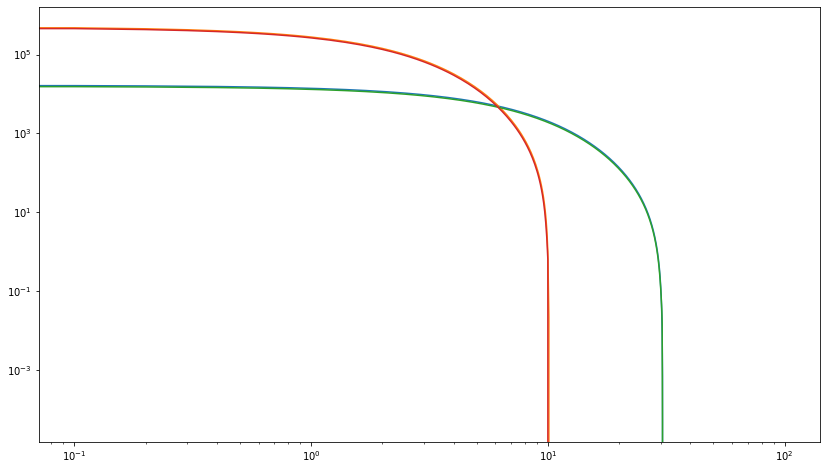

In [39]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()
ax.set_yscale("log")
ax.set_xscale("log")

plt.plot(x_Na,y_Na,label="Na")
plt.plot(x_I,y_I,label="I")

plt.plot(x_Na2,y_Na2,label="Na2")
plt.plot(x_I2,y_I2,label="I2")

#print(y)

In [ ]:
def print_mw_c(arr,
               fmt: str = "{: .8e}",
               elems_per_line: int = 8,
               var_name: str = "mw",
               const: bool = True) -> None:
    """
    Genera el vector geométricamente espaciado con np.geomspace y lo imprime
    como un literal de array de C que puedes copiar‑y‑pegar directamente.

    Parámetros
    ----------
    arr: array que quieras imprimir
    fmt : str
        Formato de cada número (por defecto 8 decimales en notación exponencial).
    elems_per_line : int
        Cantidad de elementos por línea (para mejorar la legibilidad).
    var_name : str
        Nombre de la variable C que se declarará.
    const : bool
        Si True se añade `const` al principio de la declaración.
    """

    n=len(arr)
    # 2. Construimos la línea de apertura
    const_str = "const " if const else ""
    header = f"static {const_str}double {var_name}[{n}] = {{"
    print(header)

    # 3. Imprimimos los valores, 8 por línea (puedes cambiar `elems_per_line`)
    line = "    "  # sangría de 4 espacios
    for i, val in enumerate(arr, start=1):
        line += fmt.format(val) + ", "
        if i % elems_per_line == 0:
            # terminamos la línea
            print(line.rstrip(", "))
            line = "   ,"  # reiniciamos sangría

    # Si quedó algo sin imprimir
    if line.strip():
        print(line.rstrip(", "))

    # 4. Cierre
    print("};")
    

In [14]:
import numpy as np
masdasd=np.zeros(8)
print(masdasd)

[0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
for i in range (len(masdasd)):
    masdasd[i]=np.random.rand(1)
print(masdasd)

print_mw_c(masdasd)

[0.49366922 0.09747035 0.0314899  0.74724623 0.90429462 0.62716434
 0.21296611 0.69958113]
static const double mw[8] = {
     4.93669223e-01,  9.74703453e-02,  3.14899022e-02,  7.47246230e-01,  9.04294621e-01,  6.27164339e-01,  2.12966114e-01,  6.99581135e-01

};
